# Daily Challenge - Statistics for Machine Learning

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy import stats
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [3]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [4]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = pd.read_csv("/content/drive/MyDrive/BootGenAI/Churn_Modelling.csv")

In [5]:
## TODO : make into a dataframe called df
df = pd.DataFrame(file_1)

In [6]:
## TODO : output the first 5 lines
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]


## Hypothesis 1: Age

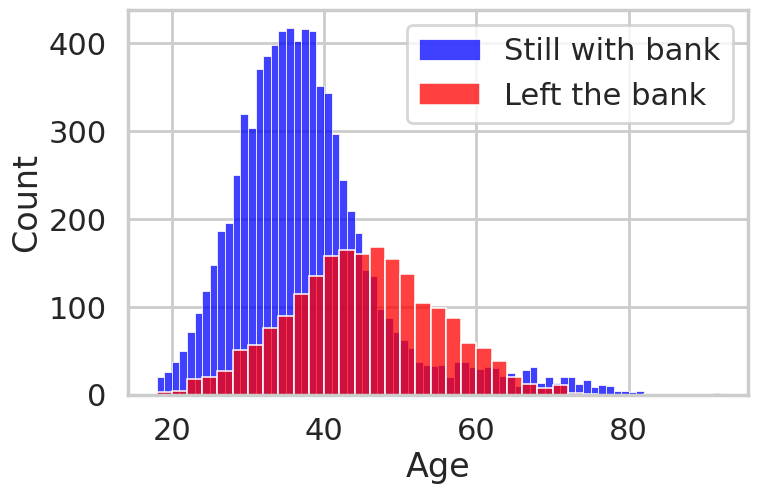

In [12]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
sns.histplot(data=df_0, x='Age', color='blue', label='Still with bank')
sns.histplot(data=df_1, x='Age', color='red', label='Left the bank')
plt.legend()
plt.show()



In [14]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
age_mean_0 = df_0["Age"].mean()
age_std_0 = df_0["Age"].std()

In [15]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
age_mean_1 = df_1["Age"].mean()
age_std_1 = df_1["Age"].std()

In [20]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
t_stat, p_value = stats.ttest_ind(df_0["Age"], df_1["Age"], equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -30.419197204406792
p-value: 4.7127272656641046e-179


### Using Bootstrapping

In [22]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
   bs_s = np.zeros(size) # store results
   n = len(data) # sample size

   for i in range(size):
    bs_abc = np.random.choice(data, size=n, replace=True)
    bs_s[i] = func(bs_abc)
    return bs_s

In [24]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
#observed diff in mean
diff_means = age_mean_0 - age_mean_1
print("Observed difference in means:", diff_means)

#shift ages to the overall mean
overall_mean = np.mean(np.concatenate([df_0["Age"], df_1["Age"]]))

# Shift each group so their mean = overall mean
shifted_stayed = df_0["Age"] - np.mean(df_0["Age"]) + overall_mean
shifted_left = df_1["Age"] - np.mean(df_1["Age"]) + overall_mean

print("Shifted stayed mean:", np.mean(shifted_stayed))
print("Shifted left mean:", np.mean(shifted_left))

Observed difference in means: -7.429608256300263
Shifted stayed mean: 38.9218
Shifted left mean: 38.92179999999999


In [25]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
import numpy as np

def bootstrap_std(data, size=1000):
    n = len(data)
    bootstrapped_stds = np.zeros(size)

    for i in range(size):
        sample = np.random.choice(data, size=n, replace=True)
        bootstrapped_stds[i] = np.std(sample, ddof=1)  # unbiased std

    return bootstrapped_stds


In [28]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.

# Ages of customers who stayed and left
ages_stayed = df_0["Age"].values
ages_left   = df_1["Age"].values

#  Observed difference in means
obs_diff = np.mean(ages_stayed) - np.mean(ages_left)

# Bootstrap distribution of differences
n_boot = 10000
boot_diffs = np.zeros(n_boot)

for i in range(n_boot):
    sample_stayed = np.random.choice(ages_stayed, size=len(ages_stayed), replace=True)
    sample_left   = np.random.choice(ages_left, size=len(ages_left), replace=True)
    boot_diffs[i] = np.mean(sample_stayed) - np.mean(sample_left)

# Calculate p-value
# Two-tailed test: proportion of bootstrap diffs as extreme as observed
p_value = np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))

print("Observed difference in means:", obs_diff)
print("Bootstrap p-value:", p_value)


Observed difference in means: -7.429608256300263
Bootstrap p-value: 0.4932


### Conclusion
We fail to reject the Null Hypothesis because the bootstrap p-value (0.4932) is much greater than 0.05.

## Hypothesis 2: Credit Score

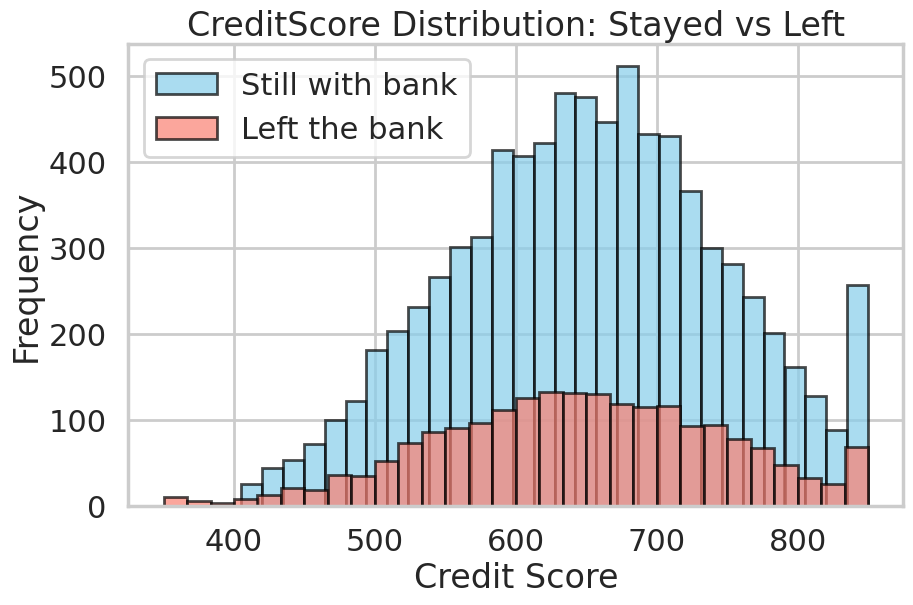

In [29]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

# Split the data into two groups
credit_stayed = df_0["CreditScore"]
credit_left   = df_1["CreditScore"]

# Create histograms
plt.figure(figsize=(10,6))

plt.hist(credit_stayed, bins=30, alpha=0.7, label="Still with bank", color="skyblue", edgecolor="black")
plt.hist(credit_left, bins=30, alpha=0.7, label="Left the bank", color="salmon", edgecolor="black")

plt.title("CreditScore Distribution: Stayed vs Left")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [30]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

# Split the data into two groups
credit_stayed = df_0["CreditScore"].values   # customers who stayed
credit_left   = df_1["CreditScore"].values   # customers who left

# Perform independent samples t-test (Welch’s t-test, safer for unequal variances)
t_stat, p_value = stats.ttest_ind(credit_stayed, credit_left, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: 2.6346605436575796
p-value: 0.008464728991832862


### Conclusion
We reject the Null Hypothesis because the p-value (0.0085) is less than 0.05.

## Hypothesis 3: Balance

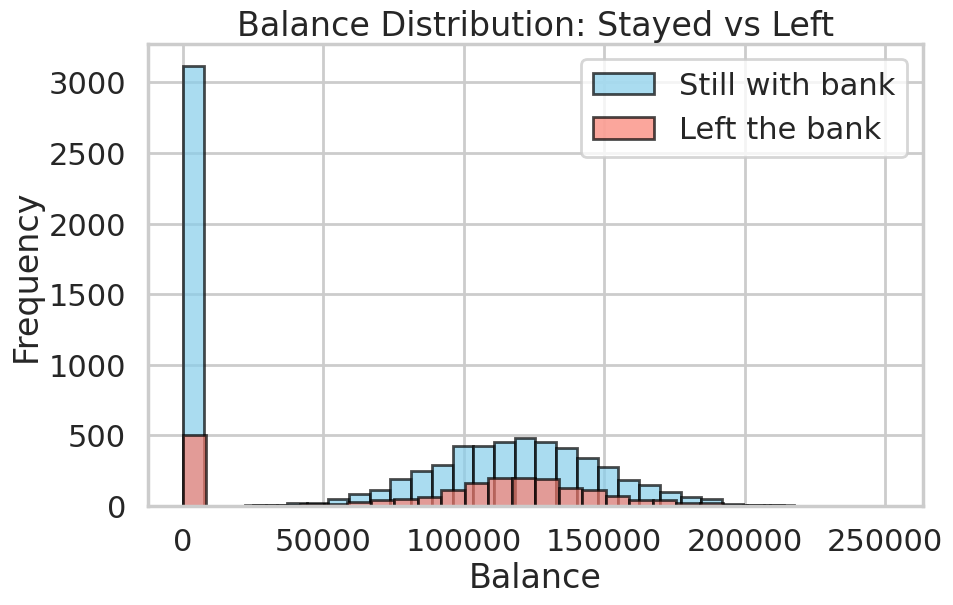

In [31]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

# Split the data into two groups
balance_stayed = df_0["Balance"]
balance_left   = df_1["Balance"]

# Plot histograms
plt.figure(figsize=(10,6))

plt.hist(balance_stayed, bins=30, alpha=0.7, label="Still with bank", color="skyblue", edgecolor="black")
plt.hist(balance_left, bins=30, alpha=0.7, label="Left the bank", color="salmon", edgecolor="black")

plt.title("Balance Distribution: Stayed vs Left")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [32]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

# Split the data into two groups
balance_stayed = df_0["Balance"].values   # customers who stayed
balance_left   = df_1["Balance"].values   # customers who left

# Perform independent samples t-test (Welch’s t-test, safer for unequal variances)
t_stat, p_value = stats.ttest_ind(balance_stayed, balance_left, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -12.471280320050688
p-value: 6.318663518527974e-35


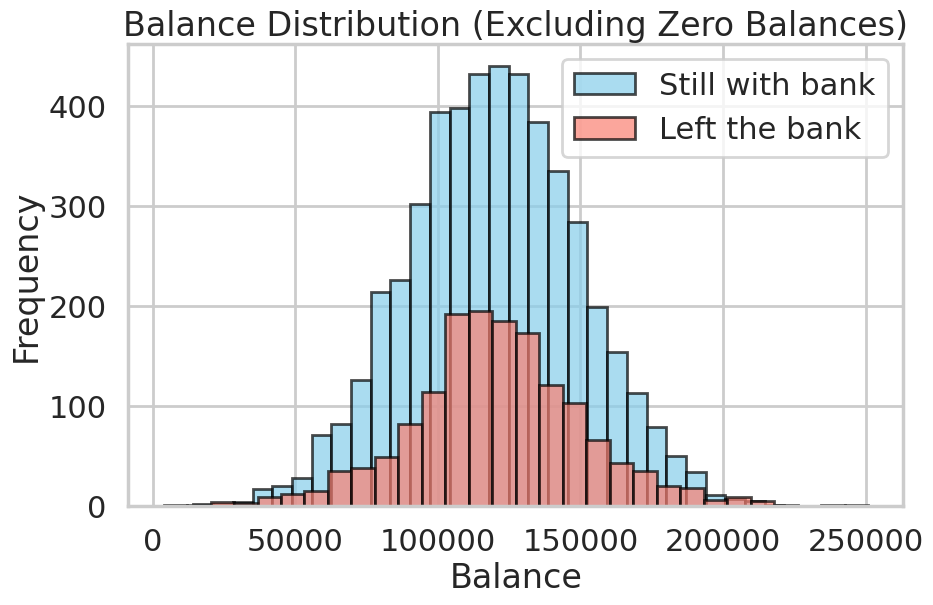

In [33]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

# Filter out zero balances
balance_stayed = df_0[df_0["Balance"] > 0]["Balance"]
balance_left   = df_1[df_1["Balance"] > 0]["Balance"]

# Plot histograms
plt.figure(figsize=(10,6))

plt.hist(balance_stayed, bins=30, alpha=0.7, label="Still with bank", color="skyblue", edgecolor="black")
plt.hist(balance_left, bins=30, alpha=0.7, label="Left the bank", color="salmon", edgecolor="black")

plt.title("Balance Distribution (Excluding Zero Balances)")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [34]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

# Filter out zero balances for both groups
balance_stayed = df_0[df_0["Balance"] > 0]["Balance"].values
balance_left   = df_1[df_1["Balance"] > 0]["Balance"].values

# Perform independent samples t-test (Welch’s t-test, safer for unequal variances)
t_stat, p_value = stats.ttest_ind(balance_stayed, balance_left, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -1.3604774889985365
p-value: 0.17379960354870824


### Conclusion
We fail to reject the Null Hypothesis because the p-value (0.174) is greater than 0.05.

## Hypothesis 4: Estimated Salary

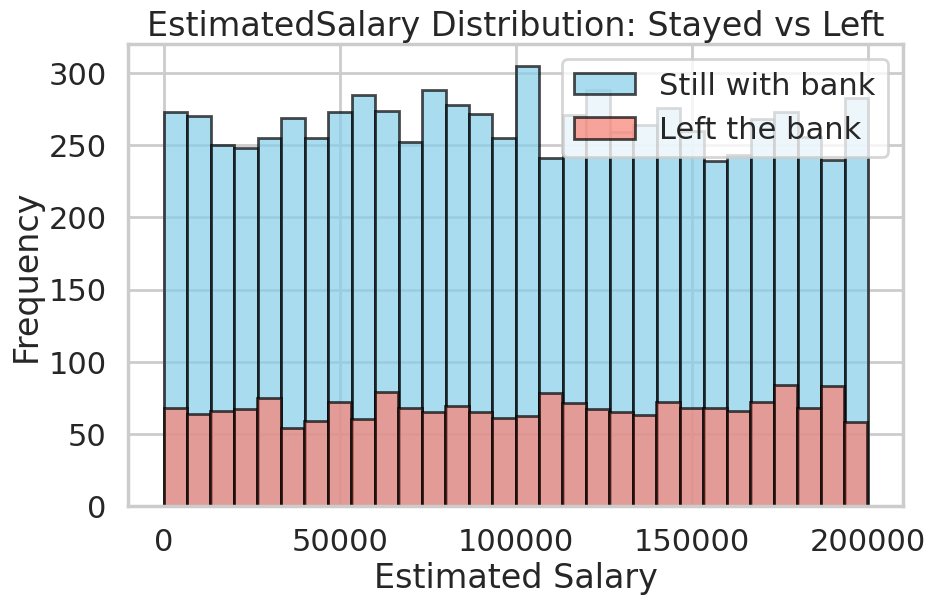

In [35]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.

# Split the data into two groups
salary_stayed = df_0["EstimatedSalary"]
salary_left   = df_1["EstimatedSalary"]

# Plot histograms
plt.figure(figsize=(10,6))

plt.hist(salary_stayed, bins=30, alpha=0.7, label="Still with bank", color="skyblue", edgecolor="black")
plt.hist(salary_left, bins=30, alpha=0.7, label="Left the bank", color="salmon", edgecolor="black")

plt.title("EstimatedSalary Distribution: Stayed vs Left")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()


In [36]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

# Split the data into two groups
salary_stayed = df_0["EstimatedSalary"].values   # customers who stayed
salary_left   = df_1["EstimatedSalary"].values   # customers who left

# Perform independent samples t-test (Welch’s t-test, safer for unequal variances)
t_stat, p_value = stats.ttest_ind(salary_stayed, salary_left, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)


t-statistic: -1.2033683196586242
p-value: 0.22892461305145795


### Using Bootstrapping

In [37]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

# Extract salaries for both groups
salary_stayed = df_0["EstimatedSalary"].values
salary_left   = df_1["EstimatedSalary"].values

# Step 1: Calculate observed difference in means
obs_diff = np.mean(salary_stayed) - np.mean(salary_left)

# Step 2: Calculate overall mean (pooled mean)
overall_mean = np.mean(np.concatenate([salary_stayed, salary_left]))

# Step 3: Shift both groups to have the same mean
shifted_stayed = salary_stayed - np.mean(salary_stayed) + overall_mean
shifted_left   = salary_left   - np.mean(salary_left)   + overall_mean

print("Observed difference in means:", obs_diff)
print("Shifted stayed mean:", np.mean(shifted_stayed))
print("Shifted left mean:", np.mean(shifted_left))


Observed difference in means: -1727.2857587371254
Shifted stayed mean: 100090.23988100002
Shifted left mean: 100090.23988100002


In [38]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
import numpy as np

# Assuming you already have shifted groups:
# shifted_stayed and shifted_left

# Step 1: Bootstrap sample means
n_boot = 10000
boot_means_stayed = np.zeros(n_boot)
boot_means_left   = np.zeros(n_boot)
boot_diffs        = np.zeros(n_boot)

for i in range(n_boot):
    sample_stayed = np.random.choice(shifted_stayed, size=len(shifted_stayed), replace=True)
    sample_left   = np.random.choice(shifted_left, size=len(shifted_left), replace=True)

    boot_means_stayed[i] = np.mean(sample_stayed)
    boot_means_left[i]   = np.mean(sample_left)
    boot_diffs[i]        = boot_means_stayed[i] - boot_means_left[i]

# Step 2: Summarize results
print("Mean bootstrap stayed:", np.mean(boot_means_stayed))
print("Mean bootstrap left:", np.mean(boot_means_left))
print("Mean bootstrap difference:", np.mean(boot_diffs))

# Confidence interval for difference
ci_diff = np.percentile(boot_diffs, [2.5, 97.5])
print("95% CI for difference:", ci_diff)


Mean bootstrap stayed: 100090.4847304467
Mean bootstrap left: 100108.0195300869
Mean bootstrap difference: -17.534799640206387
95% CI for difference: [-2856.36760208  2840.32294721]


In [39]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

# Step 1: Observed difference in means (already computed earlier)
obs_diff = np.mean(df_0["EstimatedSalary"].values) - np.mean(df_1["EstimatedSalary"].values)

# Step 2: Bootstrap distribution of differences (already computed as boot_diffs)
# boot_diffs = [...] from your previous code

# Step 3: Calculate p-value
# Two-tailed test: proportion of bootstrap diffs as extreme as observed
p_value = np.mean(np.abs(boot_diffs) >= np.abs(obs_diff))

print("Observed difference in means:", obs_diff)
print("Bootstrap p-value:", p_value)

Observed difference in means: -1727.2857587371254
Bootstrap p-value: 0.2304


### Conclusion
We fail to reject the Null Hypothesis because the bootstrap p-value (0.2304) is greater than 0.05
and the 95% confidence interval for the difference includes 0.

## Final Conclusion
Among the tested features (Age, CreditScore, Balance, EstimatedSalary), only **CreditScore**
showed a statistically significant difference between customers who stayed and those who left.
Therefore, **CreditScore is the most helpful feature in predicting churn** in this dataset.